##Import Libraries

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.7 MB/s eta 0:00:00


In [3]:
!pip install lightgbm

In [4]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# SMOTE
from imblearn.over_sampling import SMOTE

# ML Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Ensembling
from sklearn.ensemble import VotingClassifier

# Train test split and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, roc_auc_score, classification_report

##Dataset

In [5]:
df = pd.read_csv("Smart_Farming_Crop_Yield_2024.csv")

print(df.head())

    farm_id       region crop_type  soil_moisture_%  soil_pH  temperature_C  \
0  FARM0001  North India     Wheat            35.95     5.99          17.79   
1  FARM0002    South USA   Soybean            19.74     7.24          30.18   
2  FARM0003    South USA     Wheat            29.32     7.16          27.37   
3  FARM0004  Central USA     Maize            17.33     6.03          33.73   
4  FARM0005  Central USA    Cotton            19.37     5.92          33.86   

   rainfall_mm  humidity_%  sunlight_hours irrigation_type  ... sowing_date  \
0        75.62       77.03            7.27             NaN  ...  2024-01-08   
1        89.91       61.13            5.67       Sprinkler  ...  2024-02-04   
2       265.43       68.87            8.23            Drip  ...  2024-02-03   
3       212.01       70.46            5.03       Sprinkler  ...  2024-02-21   
4       269.09       55.73            7.93             NaN  ...  2024-02-05   

   harvest_date total_days yield_kg_per_hectare  s

In [6]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:", df.columns.tolist())

Dataset Shape: (500, 22)

Columns: ['farm_id', 'region', 'crop_type', 'soil_moisture_%', 'soil_pH', 'temperature_C', 'rainfall_mm', 'humidity_%', 'sunlight_hours', 'irrigation_type', 'fertilizer_type', 'pesticide_usage_ml', 'sowing_date', 'harvest_date', 'total_days', 'yield_kg_per_hectare', 'sensor_id', 'timestamp', 'latitude', 'longitude', 'NDVI_index', 'crop_disease_status']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               500 non-null    object 
 1   region                500 non-null    object 
 2   crop_type             500 non-null    object 
 3   soil_moisture_%       500 non-null    float64
 4   soil_pH               500 non-null    float64
 5   temperature_C         500 non-null    float64
 6   rainfall_mm           500 non-null    float64
 7   humidity_%            500 non-null    float64
 8   sunlight_hours        500 non-null    float64
 9   irrigation_type       350 non-null    object 
 10  fertilizer_type       500 non-null    object 
 11  pesticide_usage_ml    500 non-null    float64
 12  sowing_date           500 non-null    object 
 13  harvest_date          500 non-null    object 
 14  total_days            500 non-null    int64  
 15  yield_kg_per_hectare  5

In [8]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing Values:\n", missing)

Missing Values:
 irrigation_type        150
crop_disease_status    130
dtype: int64


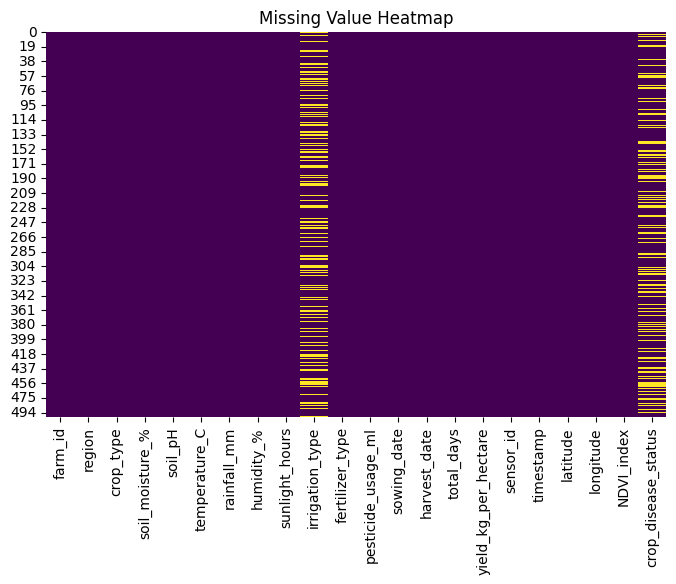

In [9]:
# missing value heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

In [10]:
#Numerical Features
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
soil_moisture_%,500.0,26.750140,10.150053,10.160000,17.890000,25.855000,36.022500,44.980000
soil_pH,500.0,6.523980,0.585558,5.510000,6.030000,6.530000,7.040000,7.500000
temperature_C,500.0,24.675740,5.348899,15.000000,20.295000,24.655000,29.090000,34.840000
rainfall_mm,500.0,181.685740,72.293091,50.170000,119.217500,191.545000,239.035000,298.960000
humidity_%,500.0,65.194460,14.642849,40.230000,51.865000,65.685000,77.995000,90.000000
sunlight_hours,500.0,7.030140,1.691670,4.010000,5.667500,6.995000,8.470000,10.000000
pesticide_usage_ml,500.0,26.586980,13.202429,5.050000,14.945000,25.980000,38.005000,49.940000
total_days,500.0,119.496000,16.798046,90.000000,105.750000,119.000000,134.000000,150.000000
yield_kg_per_hectare,500.0,4032.926940,1174.433040,2023.560000,2994.820000,4071.690000,5062.110000,5998.290000
latitude,500.0,22.442473,7.283492,10.004243,16.263202,21.981743,28.528948,34.981531


In [11]:
# Categorical Features
df.describe(include='object').T

,count,unique,top,freq
farm_id,500,500,FARM0500,1
region,500,5,Central USA,109
crop_type,500,5,Maize,111
irrigation_type,350,3,Sprinkler,121
fertilizer_type,500,3,Inorganic,167
sowing_date,500,84,2024-03-05,15
harvest_date,500,123,2024-06-28,10
sensor_id,500,500,SENS0500,1
timestamp,500,172,2024-04-14,10
crop_disease_status,370,3,Severe,133


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


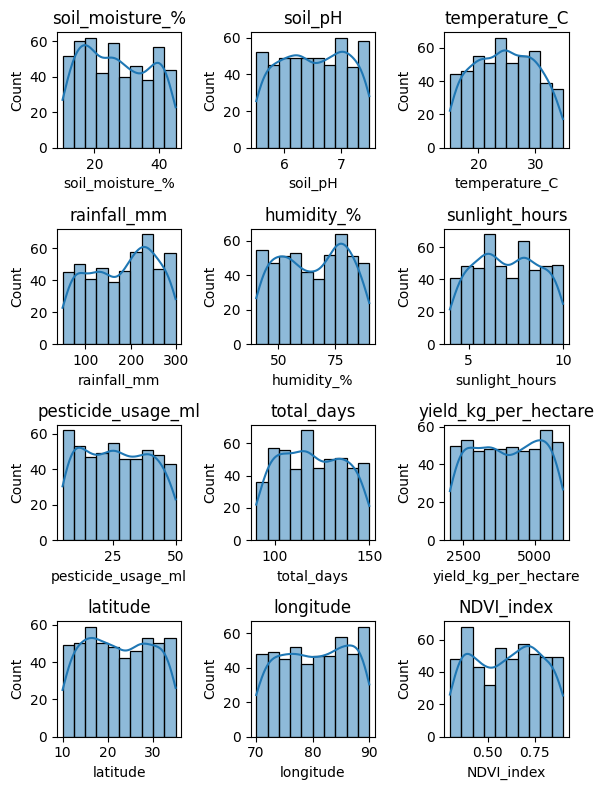

In [13]:
# Distribution Analysis of Numerical columns
import math

num_cols = df.select_dtypes(include='number').columns

n_cols=3  # number of columns per row
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(6,2*n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

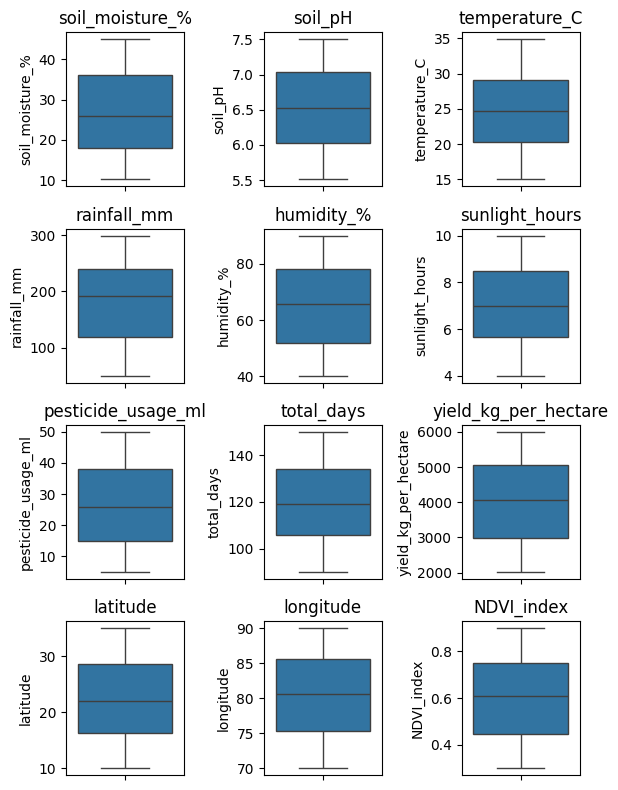

In [14]:
import math

num_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(6,2*n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

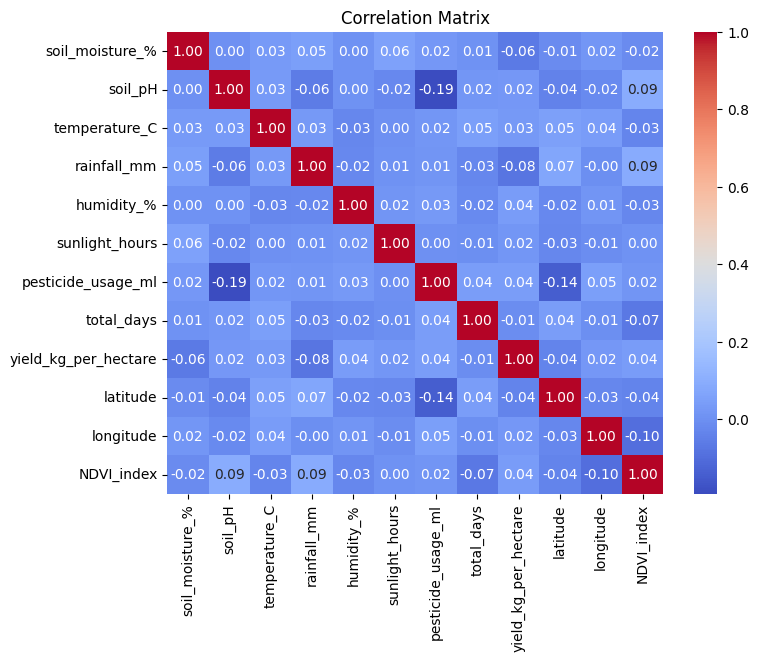

In [15]:
# Correlation Analysis
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

##Preprocessing Data

In [16]:
removed_columns = ['farm_id', 'region', 'fertilizer_type', 'pesticide_usage_ml', 'sowing_date', 'harvest_date', 'total_days', 'yield_kg_per_hectare', 'sensor_id', 'timestamp', 'latitude', 'longitude', 'crop_disease_status']
df.drop(removed_columns, axis=1, inplace=True)

In [17]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [18]:
#Handling Numerical values through Median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2763/813195533.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [19]:
#Handling catagorical values through Most frequent
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2763/1039326598.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Anomaly Detection

In [20]:
# Creating Anomaly before outlier so that most of the values do not go missing

df['Anomaly'] = 0
y_anom = df['Anomaly']

# Over-irrigation
df.loc[df['soil_moisture_%'] > 80, 'Anomaly'] = 1

# Under-irrigation
df.loc[df['soil_moisture_%'] < 15, 'Anomaly'] = 2

# Leakage (sudden drop simulation)
df['Moisture_Change'] = df['soil_moisture_%'].diff()
df.loc[df['Moisture_Change'] < -20, 'Anomaly'] = 3

# System failure (no change)
df.loc[df['Moisture_Change'] == 0, 'Anomaly'] = 4

print("Unique classes:", np.unique(y_anom))

Unique classes: [0 2 3]


Irrigation Detection

In [21]:
# checking irrigation before outlier
df['Irrigation_Need'] = (
    (df['soil_moisture_%'] < 30) &
    (df['temperature_C'] > 25) &
    (df['humidity_%'] < 60)
).astype(int)

In [22]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

df = remove_outliers(df, num_cols)
print("After removing outliers:", df.shape)

After removing outliers: (500, 12)


#EDA After Preprocessing

In [23]:
# Column names
print("\nColumns:", df.columns.tolist())


Columns: ['crop_type', 'soil_moisture_%', 'soil_pH', 'temperature_C', 'rainfall_mm', 'humidity_%', 'sunlight_hours', 'irrigation_type', 'NDVI_index', 'Anomaly', 'Moisture_Change', 'Irrigation_Need']


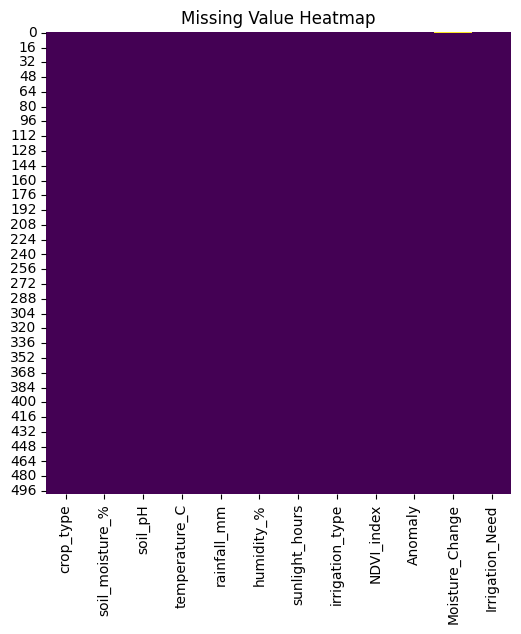

In [24]:
# missing value heatmap
plt.figure(figsize=(6,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

In [25]:
target_col = "Irrigation_Need"
df[target_col].value_counts()

,count
Irrigation_Need,
0,438
1,62


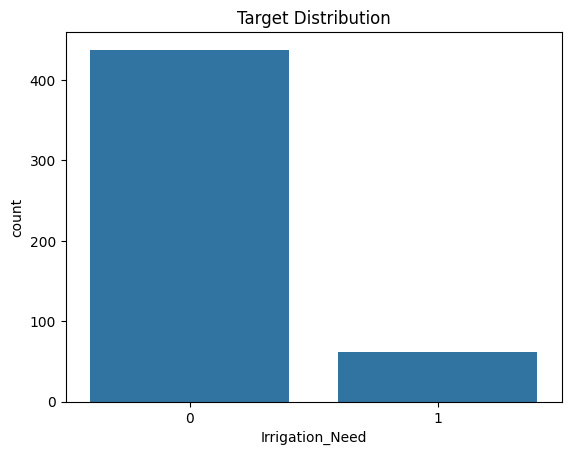

In [26]:
sns.countplot(x=df[target_col])
plt.title("Target Distribution")
plt.show()

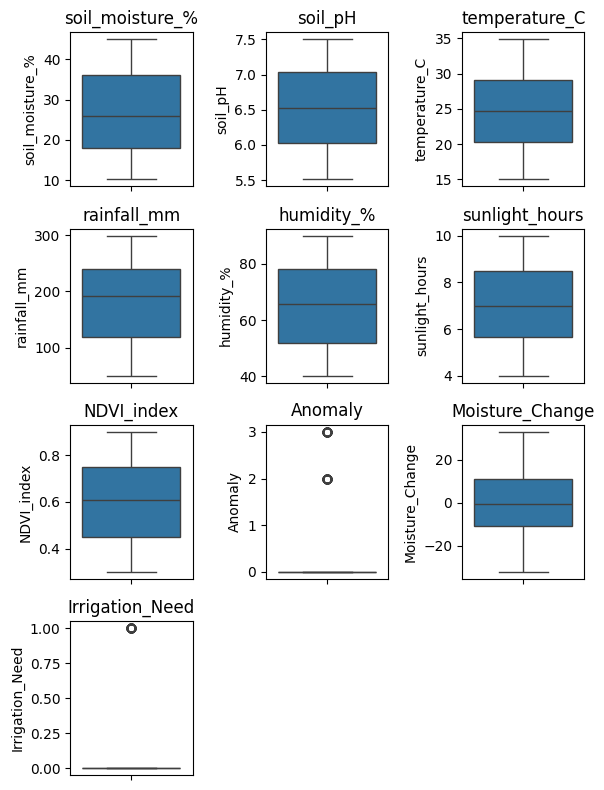

In [27]:
# Outlier Detection
import math

num_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)
plt.figure(figsize=(6, 2*n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

##Labeling

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [29]:
#df.to_csv("preprocessed_data.csv", index=False)

##Train-Test-Split

Irrigation

In [30]:
features = ['soil_pH', 'soil_moisture_%','temperature_C', 'humidity_%','sunlight_hours', 'rainfall_mm', 'irrigation_type','crop_type']
X = df[features]
y = df['Irrigation_Need']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Anomaly

In [32]:
X_anom = X
y_anom = df['Anomaly']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split( X_anom, y_anom, test_size=0.2, stratify=y_anom, random_state=42 )

In [33]:
smote_anom = SMOTE(random_state=42)

X_train_a_sm, y_train_a_sm = smote_anom.fit_resample(
    X_train_a,
    y_train_a
)

#Train Model

In [34]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_sm).value_counts())

Before SMOTE: Irrigation_Need
0    350
1     50
Name: count, dtype: int64
After SMOTE: Irrigation_Need
0    350
1    350
Name: count, dtype: int64


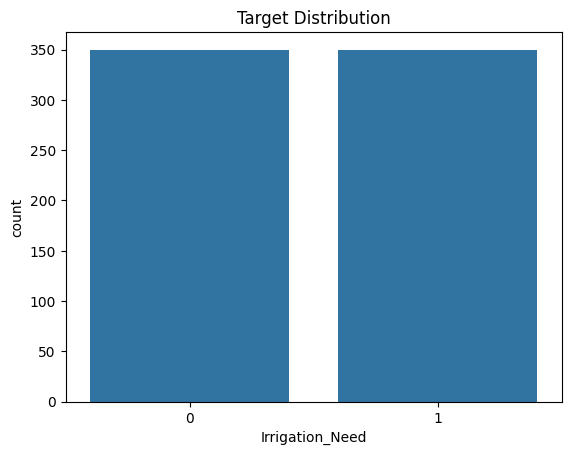

In [35]:
sns.countplot(x=y_train_sm)
plt.title("Target Distribution")
plt.show()

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scaled data
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [38]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True),

    #"XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0),

    # =========================
    # ENSEMBLE MODELS (Added for ensembling)
    # =========================

    # 1. RF + DT
    "RF + DT Ensemble": VotingClassifier(estimators=[
            ('rf', RandomForestClassifier()),
            ('dt', DecisionTreeClassifier())
        ],
        voting='soft'
    ),

    # 2. KNN + NB
    "KNN + NB Ensemble": VotingClassifier(
        estimators=[
            ('knn', KNeighborsClassifier()),
            ('nb', GaussianNB())
        ],
        voting='soft'
    ),

    # 3. XGB + SVM
    "XGB + SVM Ensemble": VotingClassifier(
        estimators=[
            ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
            ('svm', SVC(probability=True))
        ],
        voting='soft'
    ),

    # 4. CatBoost + LightGBM
    "CatBoost + LGBM Ensemble": VotingClassifier(
        estimators=[
            ('cat', CatBoostClassifier(verbose=0)),
            ('lgbm', LGBMClassifier())
        ],
        voting='soft'
    )
}

In [39]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    #print("Precision:", precision_score(y_test, y_pred))
    #print("Recall:", recall_score(y_test, y_pred))
    #print("F1 Score:", f1_score(y_test, y_pred))

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [41]:
for name, model in models.items():

    # Models that NEED scaling
    if name in ["Logistic Regression", "KNN", "SVM"]:
        evaluate_model(
            name,
            model,
            X_train_scaled,
            X_test_scaled,
            y_train_sm,
            y_test
        )

    # Tree models DO NOT need scaling
    else:
        evaluate_model(
            name,
            model,
            X_train_sm,
            X_test,
            y_train_sm,
            y_test
        )


Random Forest
Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        88
           1       1.00      0.58      0.74        12

    accuracy                           0.95       100
   macro avg       0.97      0.79      0.85       100
weighted avg       0.95      0.95      0.94       100

ROC-AUC: 1.0

Logistic Regression
Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.99      0.94      0.97        88
           1       0.69      0.92      0.79        12

    accuracy                           0.94       100
   macro avg       0.84      0.93      0.88       100
weighted avg       0.95      0.94      0.94       100

ROC-AUC: 0.9848484848484849

Decision Tree
Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        88
           1       1.00      0.83      0.91        12

    accuracy                           0.98  

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:20:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGB + SVM Ensemble
Accuracy: 0.98
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        88
           1       1.00      0.83      0.91        12

    accuracy                           0.98       100
   macro avg       0.99      0.92      0.95       100
weighted avg       0.98      0.98      0.98       100

ROC-AUC: 0.9820075757575758
[LightGBM] [Info] Number of positive: 350, number of negative: 350
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000146 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1407
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

In [42]:

rf_model = RandomForestClassifier()
rf_model.fit(X_train_sm, y_train_sm)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
#print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.97
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        88
           1       1.00      0.75      0.86        12

    accuracy                           0.97       100
   macro avg       0.98      0.88      0.92       100
weighted avg       0.97      0.97      0.97       100



In [43]:
print(df['Anomaly'].value_counts())

Anomaly
0    399
2     55
3     46
Name: count, dtype: int64


In [44]:
iso_model = IsolationForest(contamination=0.3)
df['Iso_Anomaly'] = iso_model.fit_predict(X)

# Convert (-1 → anomaly, 1 → normal)
df['Iso_Anomaly'] = df['Iso_Anomaly'].map({1: 0, -1: 1})

df['Iso_Anomaly'].head(15)

,Iso_Anomaly
0,0
1,0
2,0
3,0
4,0
5,0
6,1
7,0
8,0
9,1


In [45]:
lr_model = LogisticRegression(max_iter=1000)
#lr_model.fit(X_train_a, y_train_a)
lr_model.fit(X_train_a_sm, y_train_a_sm)

y_pred_a = lr_model.predict(X_test_a)

print("Anomaly Detection Accuracy:", accuracy_score(y_test_a, y_pred_a))

Anomaly Detection Accuracy: 0.79


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#Final Decision and Test

In [46]:
def decision_engine(row, irrigation_pred, anomaly_flag):
    moisture = row['soil_moisture_%']
    temp = row['temperature_C']
    humidity = row['humidity_%']

    # -------------------------
    # 1. HARD SAFETY CHECKS (TRUE ANOMALY)
    # -------------------------
    if anomaly_flag == 1:
        if moisture > 90:
            return " Critical: Possible Leakage Detected"
        elif moisture < 10:
            return "Sensor Error or Extreme Dry Soil"
        else:
            return "System Anomaly Detected"

    # -------------------------
    # 2. RULE-BASED IRRIGATION (PRIMARY LOGIC)
    # -------------------------
    if moisture < 30:
        return "Irrigation Needed (Soil Too Dry)"

    elif 30 <= moisture <= 60:
        return "Optimal Moisture (No Irrigation Needed)"

    elif 60 < moisture <= 80:
        return "Slightly Wet (Monitor Only)"

    elif moisture > 80:
        return "Over-Irrigation Risk (Stop Irrigation)"

    # -------------------------
    # 3. MODEL SUPPORT (SECONDARY)
    # -------------------------
    if irrigation_pred == 1:
        return "Irrigation Suggested by Model"
    else:
        return "No Irrigation Needed"

In [47]:
# Sample test rows
test_cases = [
    {"soil_moisture_%": 95, "temperature_C": 30, "humidity_%": 60},  # leakage
    {"soil_moisture_%": 5, "temperature_C": 30, "humidity_%": 60},   # extreme dry anomaly
    {"soil_moisture_%": 25, "temperature_C": 30, "humidity_%": 60},  # irrigation needed
    {"soil_moisture_%": 45, "temperature_C": 30, "humidity_%": 60},  # optimal
    {"soil_moisture_%": 70, "temperature_C": 30, "humidity_%": 60},  # slightly wet
    {"soil_moisture_%": 85, "temperature_C": 30, "humidity_%": 60},  # over-irrigation
]

# Run tests
for i, row in enumerate(test_cases):
    result = decision_engine(row, irrigation_pred=0, anomaly_flag=0)
    print(f"Test Case {i+1}: {row['soil_moisture_%']}% → {result}")

Test Case 1: 95% → Over-Irrigation Risk (Stop Irrigation)
Test Case 2: 5% → Irrigation Needed (Soil Too Dry)
Test Case 3: 25% → Irrigation Needed (Soil Too Dry)
Test Case 4: 45% → Optimal Moisture (No Irrigation Needed)
Test Case 5: 70% → Slightly Wet (Monitor Only)
Test Case 6: 85% → Over-Irrigation Risk (Stop Irrigation)


In [48]:

sample = X_test[:50]

for i in range(len(sample)):

    row = sample.iloc[i].values.reshape(1, -1)
    row_df = pd.DataFrame(row, columns=X.columns)

    #pred = rf_model.predict(row_df.values)[0]
    pred = rf_model.predict(row_df)[0]
    anom = lr_model.predict(row_df)[0]

    decision = decision_engine(row_df.iloc[0], pred, anom)

    print(f"Sample {i+1}:")
    print(f"Moisture: {row_df['soil_moisture_%'].values[0]}")
    print(f"Prediction: {pred}, Anomaly: {anom}")
    print(f"Decision: {decision}")
    print("-" * 40)


Sample 1:
Moisture: 25.75
Prediction: 0, Anomaly: 0
Decision: Irrigation Needed (Soil Too Dry)
----------------------------------------
Sample 2:
Moisture: 15.52
Prediction: 0, Anomaly: 3
Decision: Irrigation Needed (Soil Too Dry)
----------------------------------------
Sample 3:
Moisture: 17.82
Prediction: 0, Anomaly: 3
Decision: Irrigation Needed (Soil Too Dry)
----------------------------------------
Sample 4:
Moisture: 26.96
Prediction: 0, Anomaly: 0
Decision: Irrigation Needed (Soil Too Dry)
----------------------------------------
Sample 5:
Moisture: 39.9
Prediction: 0, Anomaly: 0
Decision: Optimal Moisture (No Irrigation Needed)
----------------------------------------
Sample 6:
Moisture: 10.66
Prediction: 0, Anomaly: 2
Decision: Irrigation Needed (Soil Too Dry)
----------------------------------------
Sample 7:
Moisture: 22.38
Prediction: 0, Anomaly: 0
Decision: Irrigation Needed (Soil Too Dry)
----------------------------------------
Sample 8:
Moisture: 20.69
Prediction: 0, A